# Preprocessing Data and EDA

## 1. Load data

In [2]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 3.7 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 3.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 3.6 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 3.7 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 3.9 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

# Load crawled dataset

df = pd.read_csv("../Dataset/ai_papers_clean_15k.csv")

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Dataset shape: (15000, 20)


,paper_id,title,publication_year,publication_type,citation_count,citations_per_year,referenced_works_count,topics,primary_topic,primary_subfield,primary_field,venue_source,authors,institutions,countries,doi,language,is_oa,oa_status,search_term_used
0,https://openalex.org/W2089402107,Dynamic capabilities: what are they?,2000,article,14369,532.185185,118,Business Strategy and Innovation; Capital Investment and Risk Analysis; Innovation and Knowledge...,Innovation and Knowledge Management,Strategy and Management,"Business, Management and Accounting",Strategic Management Journal,Jeffrey A. Martin; Kathleen M. Eisenhardt,Stanford University,US,https://doi.org/10.1002/1097-0266(200010/11)21:10/11<1105::aid-smj133>3.0.co;2-e,en,True,bronze,machine learning
1,https://openalex.org/W1534477342,Ensemble Methods in Machine Learning,2000,book-chapter,7783,288.259259,25,Face and Expression Recognition; Machine Learning and Data Classification; Neural Networks and A...,Neural Networks and Applications,Artificial Intelligence,Computer Science,Lecture notes in computer science,Thomas G. Dietterich,Oregon State University,US,https://doi.org/10.1007/3-540-45014-9_1,en,False,closed,machine learning
2,https://openalex.org/W2147111138,"Increasing Returns, Path Dependence, and the Study of Politics",2000,article,7613,281.962963,97,Economic Theory and Institutions; Historical Economic and Social Studies; Social Policy and Refo...,Economic Theory and Institutions,Economics and Econometrics,"Economics, Econometrics and Finance",American Political Science Review,Paul Pierson,Harvard University Press,US,https://doi.org/10.2307/2586011,en,True,green,deep learning
3,https://openalex.org/W2024046085,Additive logistic regression: a statistical view of boosting (With discussion and a rejoinder by...,2000,article,6931,256.703704,42,Advanced Statistical Methods and Models; Imbalanced Data Classification Techniques; Machine Lear...,Advanced Statistical Methods and Models,Statistics and Probability,Mathematics,The Annals of Statistics,Jerome H. Friedman; Robert Tibshirani; Trevor Hastie,Stanford University,US,https://doi.org/10.1214/aos/1016218223,en,True,bronze,artificial intelligence
4,https://openalex.org/W1608836379,Structural Equation Modeling and Regression: Guidelines for Research Practice,2000,article,6358,235.481481,85,Big Data and Business Intelligence; Complex Systems and Decision Making; Technology Adoption and...,Big Data and Business Intelligence,Management Information Systems,"Business, Management and Accounting",Communications of the Association for Information Systems,David Gefen; Detmar W. Straub; Marie‐Claude Boudreau,Drexel University; Georgia State University; University of Georgia,US,https://doi.org/10.17705/1cais.00407,en,True,bronze,artificial intelligence


## 2. Data Overview

In [6]:
# ============================================================
# BASIC DATA OVERVIEW
# ============================================================

print("\n================ DATA INFO ================\n")

df.info()

print("\n================ MISSING VALUES ================\n")

missing = df.isna().sum().sort_values(ascending=False)

print(missing)

print("\n================ DUPLICATES ================\n")

duplicates = df.duplicated(subset=["paper_id"]).sum()

print("Duplicate papers:", duplicates)


================ DATA INFO ================

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   paper_id                15000 non-null  str    
 1   title                   14994 non-null  str    
 2   publication_year        15000 non-null  int64  
 3   publication_type        15000 non-null  str    
 4   citation_count          15000 non-null  int64  
 5   citations_per_year      15000 non-null  float64
 6   referenced_works_count  15000 non-null  int64  
 7   topics                  15000 non-null  str    
 8   primary_topic           15000 non-null  str    
 9   primary_subfield        15000 non-null  str    
 10  primary_field           15000 non-null  str    
 11  venue_source            13342 non-null  str    
 12  authors                 14941 non-null  str    
 13  institutions            14247 non-null  str    
 14  cou

## 3. Data cleaning

In [7]:
# ============================================================
# DATA CLEANING
# ============================================================

print("\n================ DATA CLEANING ================\n")

# Remove duplicates
df = df.drop_duplicates(subset=["paper_id"])

# Fill missing values
df["venue_source"] = df["venue_source"].fillna("Unknown Venue")
df["language"] = df["language"].fillna("unknown")
df["oa_status"] = df["oa_status"].fillna("unknown")

# Convert numeric columns
df["publication_year"] = pd.to_numeric(
    df["publication_year"],
    errors="coerce"
)

df["citation_count"] = pd.to_numeric(
    df["citation_count"],
    errors="coerce"
)

# Remove invalid years
df = df[df["publication_year"].notna()]

# Convert to integer
df["publication_year"] = df["publication_year"].astype(int)

# Fill missing citations
df["citation_count"] = df["citation_count"].fillna(0)

print("Dataset shape after cleaning:", df.shape)




================ DATA CLEANING ================

Dataset shape after cleaning: (15000, 20)


## 4. Feature Engineering

In [8]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

print("\n================ FEATURE ENGINEERING ================\n")

CURRENT_YEAR = 2026

# Paper age
df["paper_age"] = (
    CURRENT_YEAR - df["publication_year"] + 1
)

# Citation velocity
df["citation_velocity"] = (
    df["citation_count"] / df["paper_age"]
)

# Count authors
df["author_count"] = (
    df["authors"]
    .fillna("")
    .apply(lambda x: len(str(x).split(";")))
)

# Count institutions
df["institution_count"] = (
    df["institutions"]
    .fillna("")
    .apply(lambda x: len(str(x).split(";")))
)

# Count countries
df["country_count"] = (
    df["countries"]
    .fillna("")
    .apply(lambda x: len(str(x).split(";")))
)

print(df[[
    "paper_age",
    "citation_velocity",
    "author_count",
    "institution_count",
    "country_count"
]].head())




================ FEATURE ENGINEERING ================

   paper_age  citation_velocity  author_count  institution_count  \
0         27         532.185185             2                  1   
1         27         288.259259             1                  1   
2         27         281.962963             1                  1   
3         27         256.703704             3                  1   
4         27         235.481481             3                  3   

   country_count  
0              1  
1              1  
2              1  
3              1  
4              1  


## 5. EDA (Exploratory Data Analysis)


================ EDA 1: PUBLICATION GROWTH ================

publication_year
2000     175
2001     157
2002     181
2003     210
2004     265
2005     262
2006     271
2007     279
2008     342
2009     331
2010     374
2011     367
2012     394
2013     429
2014     551
2015     712
2016     894
2017    1201
2018    1492
2019    1613
2020    1764
2021    1093
2022     770
2023     637
2024     210
2025      25
2026       1
Name: count, dtype: int64


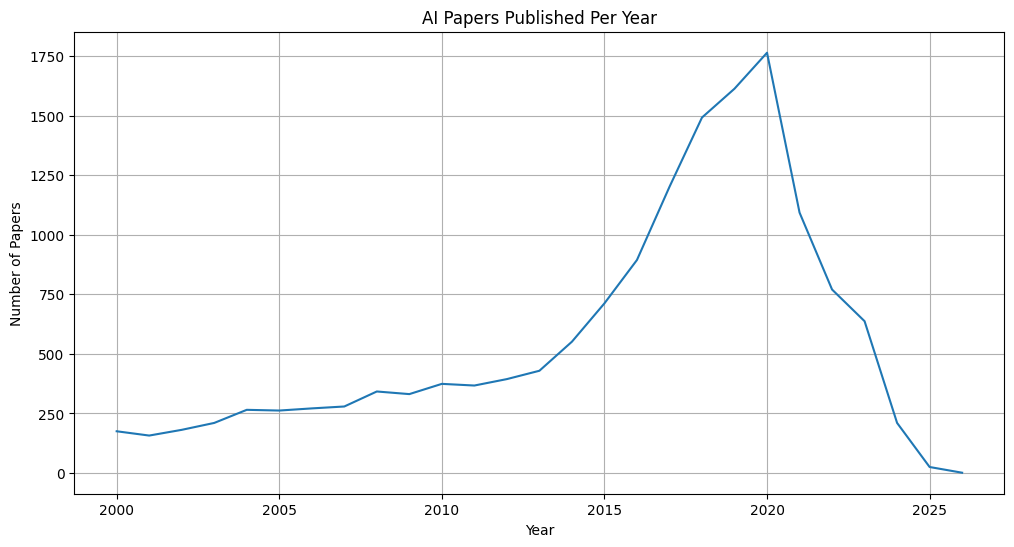


================ EDA 2: CITATION DISTRIBUTION ================

count     15000.000000
mean        982.200533
std        3078.912487
min         258.000000
25%         396.000000
50%         560.000000
75%         870.000000
max      220504.000000
Name: citation_count, dtype: float64


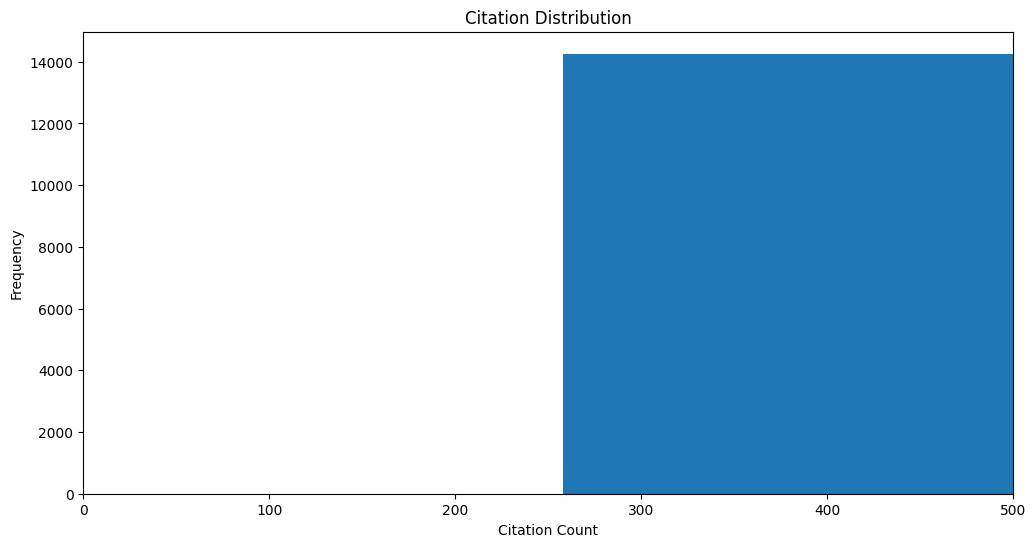


================ EDA 3: TOP AI TOPICS ================

primary_topic
Topic Modeling                                         433
Artificial Intelligence in Healthcare and Education    292
Advanced Neural Network Applications                   237
Natural Language Processing Techniques                 228
Machine Learning in Materials Science                  188
Ethics and Social Impacts of AI                        155
Digital Transformation in Industry                     149
Privacy-Preserving Technologies in Data                144
Domain Adaptation and Few-Shot Learning                135
COVID-19 diagnosis using AI                            132
Smart Agriculture and AI                               131
Computational Drug Discovery Methods                   128
Sentiment Analysis and Opinion Mining                  127
Network Security and Intrusion Detection               126
Explainable Artificial Intelligence (XAI)              117
Name: count, dtype: int64


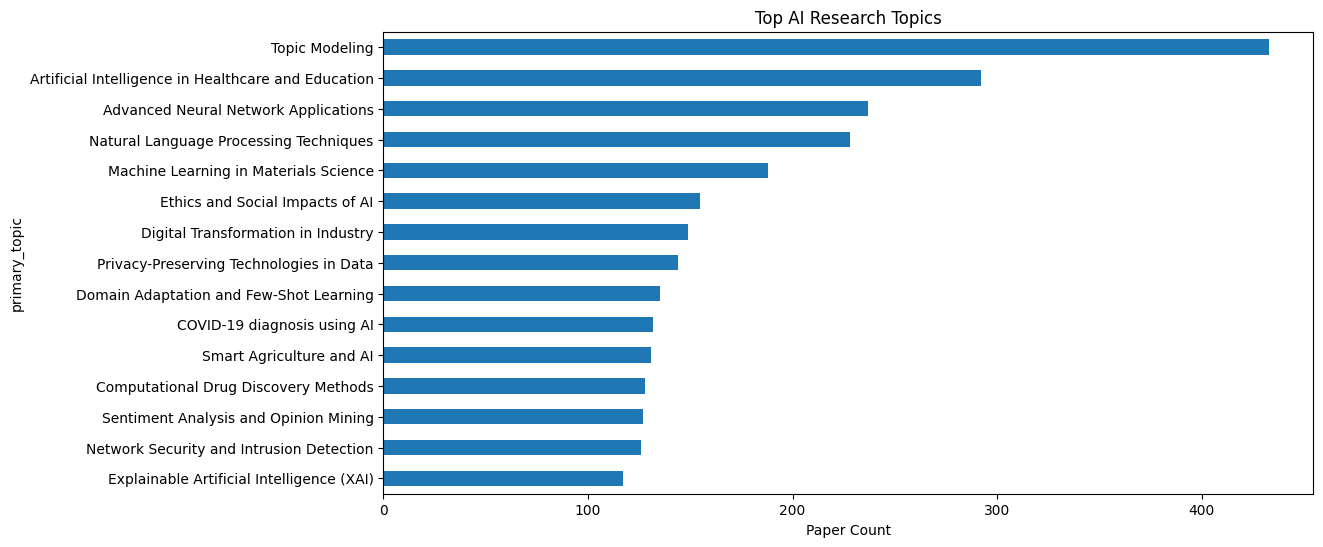


================ EDA 4: OPEN ACCESS ================

is_oa
True     12147
False     2853
Name: count, dtype: int64


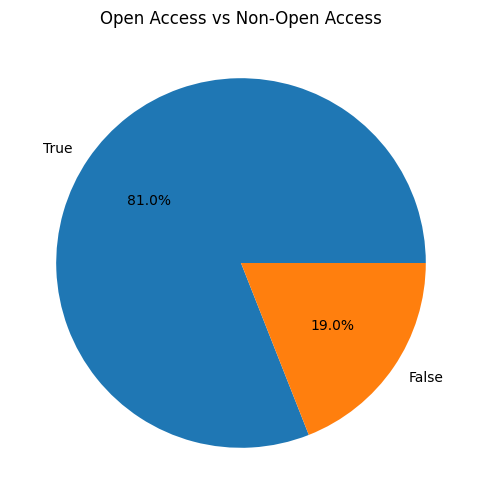


================ EDA 5: COUNTRY CONCENTRATION ================

countries
US    6804
GB    2967
CN    2391
DE    1636
CA    1134
AU    1095
NL     975
FR     933
IT     763
CH     693
ES     644
IN     564
SG     457
JP     449
KR     440
Name: count, dtype: int64


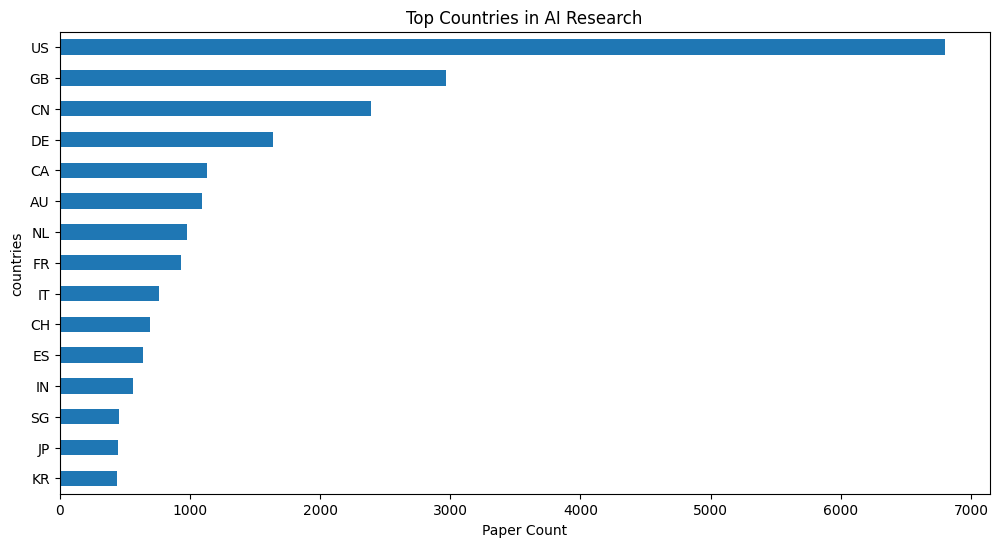


================ EDA 6: TOP INSTITUTIONS ================

institutions
Stanford University                             534
Harvard University                              458
Massachusetts Institute of Technology           421
University of California, Berkeley              369
University College London                       352
University of Oxford                            345
Centre National de la Recherche Scientifique    311
University of Cambridge                         304
University of Washington                        285
Chinese Academy of Sciences                     271
Carnegie Mellon University                      264
Google (United States)                          257
Tsinghua University                             252
University of Toronto                           244
Imperial College London                         238
Name: count, dtype: int64


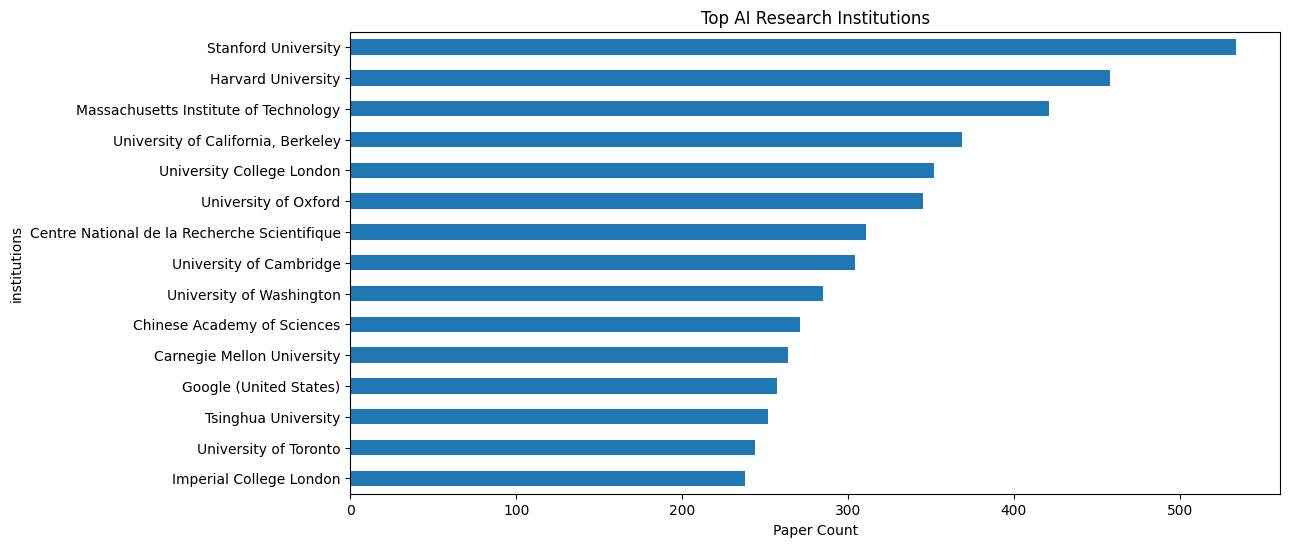


================ EDA 7: PUBLICATION TYPES ================

publication_type
article         13901
preprint          756
book-chapter      343
Name: count, dtype: int64


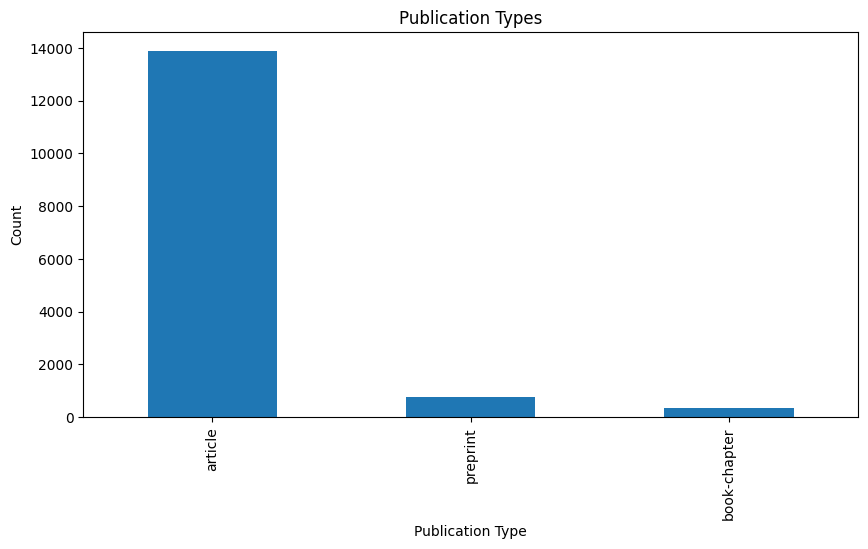


================ EDA 8: CITATION VELOCITY ================

count    15000.000000
mean       103.539660
std        340.808024
min          9.814815
25%         39.125000
50%         59.800000
75%         96.818182
max      20045.818182
Name: citation_velocity, dtype: float64


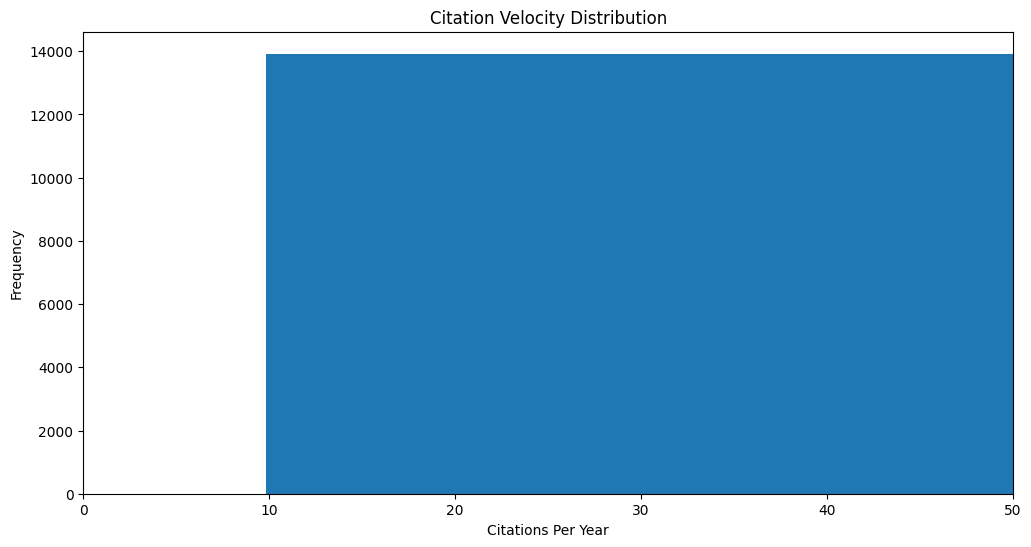


================ EDA 9: YEARLY CITATION TREND ================

publication_year
2000    1122.291429
2001    1959.000000
2002    1103.994475
2003     995.895238
2004    1009.332075
2005    1309.400763
2006    1078.372694
2007    1054.709677
2008    1073.362573
2009    1223.755287
2010    1126.518717
2011    1071.937330
2012    1191.847716
2013    1004.986014
2014    1262.441016
2015    1286.566011
2016    1338.480984
2017    1127.680266
2018     870.551609
2019     784.393056
2020     731.725057
2021     873.627630
2022     622.383117
2023     748.246468
2024     893.495238
2025     729.360000
2026    1396.000000
Name: citation_count, dtype: float64


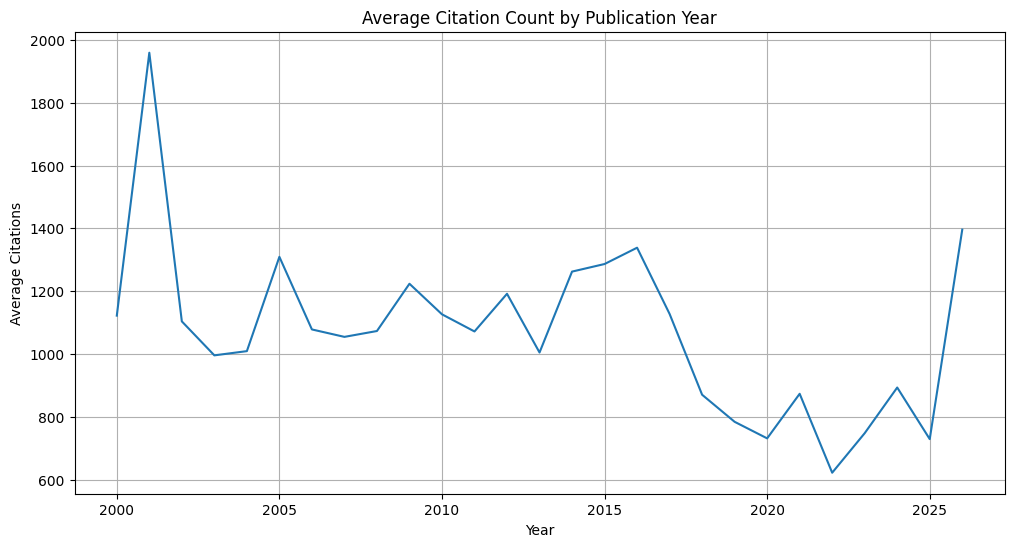


Processed dataset saved successfully.
Saved to: ../Dataset/ai_papers_processed.csv

Final dataset shape: (15000, 25)


In [9]:
# ============================================================
# EDA 1 — PUBLICATION GROWTH OVER TIME
# ============================================================

print("\n================ EDA 1: PUBLICATION GROWTH ================\n")

papers_per_year = (
    df["publication_year"]
    .value_counts()
    .sort_index()
)

print(papers_per_year)

plt.figure(figsize=(12,6))

papers_per_year.plot()

plt.title("AI Papers Published Per Year")

plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.grid(True)

plt.show()

# Insight:
# We expect rapid AI publication growth after 2015,
# with strong acceleration after the rise of deep learning
# and generative AI.


# ============================================================
# EDA 2 — CITATION DISTRIBUTION
# ============================================================

print("\n================ EDA 2: CITATION DISTRIBUTION ================\n")

print(df["citation_count"].describe())

plt.figure(figsize=(12,6))

plt.hist(
    df["citation_count"],
    bins=100
)

plt.xlim(0, 500)

plt.title("Citation Distribution")

plt.xlabel("Citation Count")
plt.ylabel("Frequency")

plt.show()

# Insight:
# Citation distribution is usually highly skewed.
# Most papers receive low citations,
# while a small number dominate scientific attention.


# ============================================================
# EDA 3 — TOP AI TOPICS
# ============================================================

print("\n================ EDA 3: TOP AI TOPICS ================\n")

top_topics = (
    df["primary_topic"]
    .value_counts()
    .head(15)
)

print(top_topics)

plt.figure(figsize=(12,6))

top_topics.sort_values().plot(kind="barh")

plt.title("Top AI Research Topics")

plt.xlabel("Paper Count")

plt.show()

# Insight:
# Dominant AI topics may include:
# - Deep Learning
# - NLP
# - LLM
# - Computer Vision
# - Reinforcement Learning


# ============================================================
# EDA 4 — OPEN ACCESS ANALYSIS
# ============================================================

print("\n================ EDA 4: OPEN ACCESS ================\n")

oa_counts = df["is_oa"].value_counts()

print(oa_counts)

plt.figure(figsize=(6,6))

oa_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Open Access vs Non-Open Access")

plt.ylabel("")

plt.show()

# Insight:
# This analysis shows the proportion of open-access
# AI research publications.


# ============================================================
# EDA 5 — COUNTRY CONCENTRATION
# ============================================================

print("\n================ EDA 5: COUNTRY CONCENTRATION ================\n")

country_series = (
    df["countries"]
    .dropna()
    .str.split("; ")
    .explode()
)

top_countries = (
    country_series
    .value_counts()
    .head(15)
)

print(top_countries)

plt.figure(figsize=(12,6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top Countries in AI Research")

plt.xlabel("Paper Count")

plt.show()

# Insight:
# This helps identify geographic concentration
# of AI research activity and institutional power.


# ============================================================
# EDA 6 — TOP INSTITUTIONS
# ============================================================

print("\n================ EDA 6: TOP INSTITUTIONS ================\n")

institution_series = (
    df["institutions"]
    .dropna()
    .str.split("; ")
    .explode()
)

top_institutions = (
    institution_series
    .value_counts()
    .head(15)
)

print(top_institutions)

plt.figure(figsize=(12,6))

top_institutions.sort_values().plot(kind="barh")

plt.title("Top AI Research Institutions")

plt.xlabel("Paper Count")

plt.show()

# Insight:
# This reveals institutional dominance
# in global AI research.


# ============================================================
# EDA 7 — PUBLICATION TYPES
# ============================================================

print("\n================ EDA 7: PUBLICATION TYPES ================\n")

publication_types = (
    df["publication_type"]
    .value_counts()
)

print(publication_types)

plt.figure(figsize=(10,5))

publication_types.plot(kind="bar")

plt.title("Publication Types")

plt.xlabel("Publication Type")
plt.ylabel("Count")

plt.show()

# Insight:
# Most AI research papers are usually articles
# and conference proceedings.


# ============================================================
# EDA 8 — CITATION VELOCITY
# ============================================================

print("\n================ EDA 8: CITATION VELOCITY ================\n")

print(df["citation_velocity"].describe())

plt.figure(figsize=(12,6))

plt.hist(
    df["citation_velocity"],
    bins=100
)

plt.xlim(0, 50)

plt.title("Citation Velocity Distribution")

plt.xlabel("Citations Per Year")

plt.ylabel("Frequency")

plt.show()

# Insight:
# Citation velocity measures how fast papers
# gain scientific attention over time.


# ============================================================
# EDA 9 — YEARLY CITATION TREND
# ============================================================

print("\n================ EDA 9: YEARLY CITATION TREND ================\n")

yearly_citations = (
    df.groupby("publication_year")["citation_count"]
    .mean()
)

print(yearly_citations)

plt.figure(figsize=(12,6))

yearly_citations.plot()

plt.title("Average Citation Count by Publication Year")

plt.xlabel("Year")

plt.ylabel("Average Citations")

plt.grid(True)

plt.show()

# Insight:
# Older papers generally accumulate more citations,
# while newer papers may have lower citation counts
# due to limited exposure time.


# ============================================================
# 6. SAVE PROCESSED DATASET
# ============================================================

OUTPUT_FILE = "../Dataset/ai_papers_processed.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\nProcessed dataset saved successfully.")
print("Saved to:", OUTPUT_FILE)

print("\nFinal dataset shape:", df.shape)